# Data Preparation Pipeline

This notebook prepares the Udacity driving log data for training a steering-angle prediction model. Down below is a summary of each preprocessing step.

## 1. Load the Data
The `driving_log.csv` file has no headers, so columns are manually named: `Center`, `Left`, `Right`, `Steering`, `Throttle`, `Brake`, `Speed`. For the project requirements, only the **Center** image path and **Steering** angle are used.

## 2. Inspect Raw Distribution
A histogram of steering angles is plotted before any changes. This typically reveals a large spike at `0.0`, since most driving is straight-line. This imbalance would bias the model toward driving straight.

## 3. Balance the Dataset
To prevent the model from "drive straight" all the time. The excess steering samples that has 0.0 are randomly dropped (currently 80% dropped). This way flattens the spike into a natural, bell-shaped distribution without discarding the samples that contain sharp turns.

## 4. Train/Validation Split
The dataset is split into training and validation sets **before** any augmentation is applied. This ensures validation data stays completely raw and unmodified which represents real-world model performance.

## 5. Data Augmentation (Training Set Only)
To improve generalization, five augmentation techniques are implemented:
- **Flip** — mirrors the image horizontally and negates the steering angle
- **Brightness** — randomly brightens/darkens the image (simulates lighting conditions)
- **Zoom** — randomly crops and rescales (simulates distance variation)
- **Pan** — randomly shifts the image (simulates off-center positioning)
- **Rotation** — randomly rotates slightly (simulates camera tilt)

Each technique fires independently with its own probability, and augmentation is applied to only a portion of images — not uniformly across the whole dataset. Augmentation is applied exclusively within the training generator; the validation generator never modifies its images.

## 6. Batch Generators
Rather than loading all images into memory, `batch_generator()` functions yield batches on the fly. An `is_training` flag controls whether augmentation logic runs, keeping the train/validation separation enforced at the data-loading level.


In [11]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading The Data

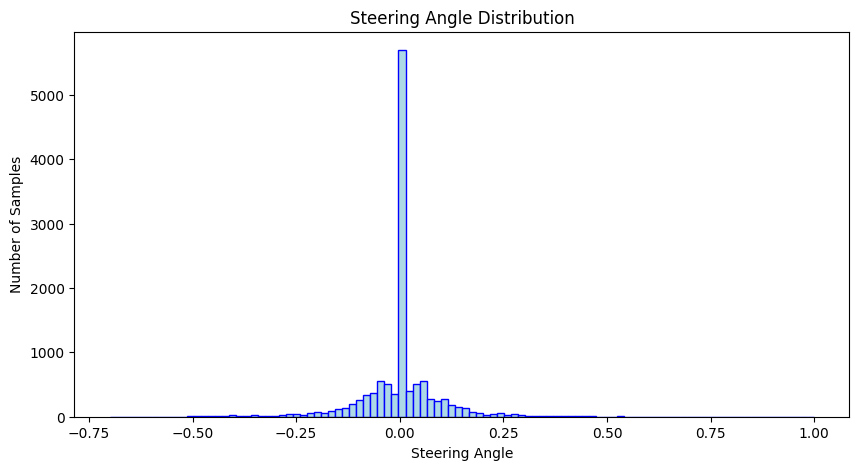

In [12]:
#1. read data
# Note: The CSV from Udacity doesn't have headers, so use names=columns.
columns = ['Center', 'Left', 'Right', 'Steering', 'Throttle', 'Brake', 'Speed']
data = pd.read_csv('driving_log.csv', names=columns)

#2. will use only the center camera images and the steering angle
center_images = data['Center'].values
steering_angles = data['Steering'].values

#3. plot the histogram to check the data balance
num_bins = 100
plt.figure(figsize=(10, 5))
hist, bins, _ = plt.hist(steering_angles, bins=num_bins, color='lightblue', edgecolor='blue')
plt.title('Steering Angle Distribution')
plt.xlabel('Steering Angle')
plt.ylabel('Number of Samples')
plt.show()

# NOTE: If the histogram shows a massive spike at 0.0 (driving straight),
# write logic here to drop a percentage of those 0.0 values to flatten/balance the histogram

## Balancing The Dataset

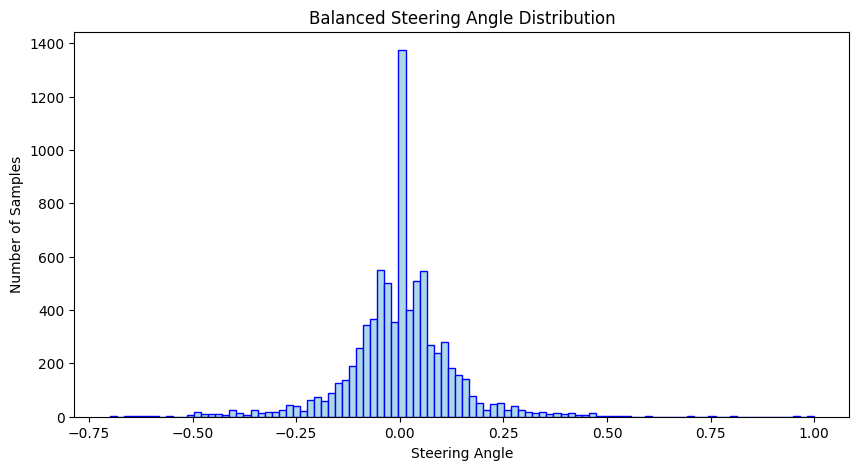

Original Total Images: 12365
Balanced Total Images: 8044


In [13]:
# get all rows that the steering angle is 0.0
zero_steering = data[data['Steering'] == 0.0]

# randomly select a percentage to drop
# dropping 80% of the 0.0 values (frac=0.8)
drop_indices = zero_steering.sample(frac=0.8, random_state=42).index

# create a new dataframe by dropping the indices (balanced version)
balanced_data = data.drop(drop_indices)

center_images = balanced_data['Center'].values
steering_angles = balanced_data['Steering'].values

plt.figure(figsize=(10, 5))
plt.hist(steering_angles, bins=num_bins, color='lightblue', edgecolor='blue')
plt.title('Balanced Steering Angle Distribution')
plt.xlabel('Steering Angle')
plt.ylabel('Number of Samples')
plt.show()

# removed data comparison
print(f"Original Total Images: {len(data)}")
print(f"Balanced Total Images: {len(balanced_data)}")

## Data Augmentation & Preprocessing

In [14]:
from sklearn.model_selection import train_test_split

#-----Split into train/validation before augmenting-----
# augmentation  is only for the training set. if augmenting is done before splitting 
# then it will effect the validation, by giving false positives.

X_train, X_valid, y_train, y_valid = train_test_split(
    center_images, steering_angles, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_valid)}")


#-----Individual Augmentation Functions-----

"""Flip image horizontally, reverse the steering angle"""
def random_flip(image, steering_angle):
    image = cv2.flip(image, 1)
    steering_angle = -steering_angle
    return image, steering_angle

"""Randomly brighten or darken the image"""
def random_brightness(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float64)
    ratio = 1.0 + np.random.uniform(-0.4, 0.4)   # 0.6x -- 1.4x brightness
    hsv[:,:,2] = np.clip(hsv[:, :, 2]* ratio, 0, 255)
    image = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    return image


"""Randomly zoom in on the image (to represent distance changes)"""
def random_zoom(image):
    zoom_factor = np.random.uniform(1.0, 1.3)
    h, w = image.shape[:2]
    new_h, new_w = int(h / zoom_factor), int(w / zoom_factor)
    top = np.random.randint(0, h - new_h + 1)
    left = np.random.randint(0, w - new_w + 1)
    cropped = image[top:top + new_h, left:left + new_w]
    image = cv2.resize(cropped, (w, h))
    return image

"""
Randomly shift the image horizontally or vertically (to represent off-center driving positions)
"""
def random_pan(image):
    h, w = image.shape[:2]
    tx = np.random.uniform(-0.1, 0.1) * w   # shift up to 10% of width
    ty = np.random.uniform(-0.1, 0.1) * h   # shift up to 10% of height
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    image = cv2.warpAffine(image, M, (w, h))
    return image

"""Randomly rotate the image (slight camera tilt to be realistic)"""
def random_rotation(image):
    h, w = image.shape[:2]
    angle = np.random.uniform(-10, 10)   # small angle, +/-10 degrees
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    image = cv2.warpAffine(image, M, (w, h))
    return image



#-----Combine Augmentations-----
# transformations should be applied to some part of the data
# each technique is applied randomly. This way creates natural varieties
# meaning that some images get 0 augmentations 
# while some get only 1 and some get several which shows diversity.

def augment_image(image, steering_angle):
    # each technique has probability of being applied.
    # probability values can be altered accordingly

    if np.random.rand() < 0.5:
        image, steering_angle = random_flip(image, steering_angle)

    if np.random.rand() < 0.5:
        image = random_brightness(image)

    if np.random.rand() < 0.3:
        image = random_zoom(image)

    if np.random.rand() < 0.3:
        image = random_pan(image)

    if np.random.rand() < 0.3:
        image = random_rotation(image)

    return image, steering_angle

#-----Data Preprocessing-----
def preprocess_image(image):
    
    
    image = image[60:135, :, :] #crop road area
    image = cv2.cvtColor(image, cv2.COLOR_RGB2YUV) #convert colour
    image = cv2.resize(image, (200, 66)) #resize image
    image = image / 255.0 #normalizatiopn
    image = cv2.GaussianBlur(image, (3, 3), 0) #guassian blur

    
    return image


#-----Generator to merge all the logic as one to apply augmentation-----
# This part is for loading the images to memory in small batches (training part)
# is_training: this flag is for controlling the augmentation (it runs when it is True)

def batch_generator(image_paths, steering_angles, batch_size, is_training):
    num_samples = len(image_paths)

    while True:  
        batch_images = []
        batch_angles = []

        indices = np.random.choice(num_samples, batch_size)

        for i in indices:
            image = cv2.imread(image_paths[i])
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            angle = steering_angles[i]

            # augmentation applied to the training dataset
            if is_training and np.random.rand() < 0.6:
                image, angle = augment_image(image, angle)

            # apply preprocessing to both training and validation images
            image = preprocess_image(image)

            batch_images.append(image)
            batch_angles.append(angle)

        # output must be converted to NumPy arrays for scikit-learn.
        yield np.array(batch_images), np.array(batch_angles)


# create the actual generators for training
train_generator = batch_generator(X_train, y_train, batch_size=32, is_training=True)
valid_generator = batch_generator(X_valid, y_valid, batch_size=32, is_training=False)


Training samples: 6435
Validation samples: 1609


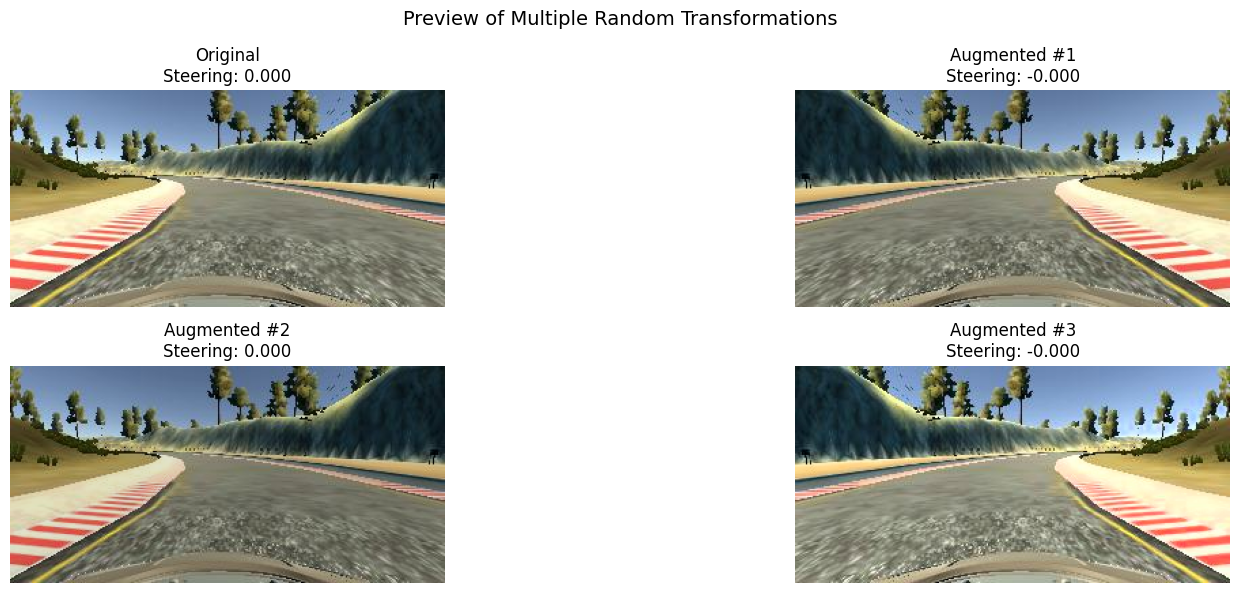

In [15]:
#-----Augmentation Test-----

# load the sample
main_image = cv2.imread("IMG/center_2026_08_01_17_52_22_732.jpg")
main_image = cv2.cvtColor(main_image, cv2.COLOR_BGR2RGB)
sample_angle = 0.0

# number of random augmentations to generate and preview
num_samples = 3

fig, axes = plt.subplots(2, (num_samples // 2) + 1, figsize=(18, 6))
axes = axes.flatten()

# original image plotted first
axes[0].imshow(main_image)
axes[0].set_title(f"Original\nSteering: {sample_angle:.3f}")
axes[0].axis('off')

# plotting augmented versions
for i in range(1, num_samples + 1):
    aug_image, aug_angle = augment_image(main_image.copy(), sample_angle)
    axes[i].imshow(aug_image)
    axes[i].set_title(f"Augmented #{i}\nSteering: {aug_angle:.3f}")
    axes[i].axis('off')

plt.suptitle("Preview of Multiple Random Transformations", fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

def net():
    model = Sequential([
        Conv2D(24, (5, 5), strides=(2, 2), activation='elu', input_shape=(66, 200, 3)),
        Conv2D(36, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(48, (5, 5), strides=(2, 2), activation='elu'),
        Conv2D(64, (3, 3), activation='elu'),
        Conv2D(64, (3, 3), activation='elu'),
        Flatten(),
        Dense(1164, activation='elu'),
        Dense(100, activation='elu'),
        Dense(50, activation='elu'),
        Dense(10, activation='elu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mse'
    )

    return model

model = net()
model.summary()



Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_15 (Conv2D)           (None, 31, 98, 24)        1824      
_________________________________________________________________
conv2d_16 (Conv2D)           (None, 14, 47, 36)        21636     
_________________________________________________________________
conv2d_17 (Conv2D)           (None, 5, 22, 48)         43248     
_________________________________________________________________
conv2d_18 (Conv2D)           (None, 3, 20, 64)         27712     
_________________________________________________________________
conv2d_19 (Conv2D)           (None, 1, 18, 64)         36928     
_________________________________________________________________
flatten_3 (Flatten)          (None, 1152)              0         
_________________________________________________________________
dense_15 (Dense)             (None, 1164)             

In [24]:
batch_size = 32
steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_valid) // batch_size 
epochs = 10

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_generator,
    validation_steps=validation_steps,
    epochs=epochs,
    verbose=1
)


Epoch 1/10
201/201 [==============================] - 13s 66ms/step - loss: 0.0229 - val_loss: 0.0108
Epoch 2/10
201/201 [==============================] - 15s 76ms/step - loss: 0.0131 - val_loss: 0.0079
Epoch 3/10
201/201 [==============================] - 11s 57ms/step - loss: 0.0131 - val_loss: 0.0085
Epoch 4/10
201/201 [==============================] - 12s 58ms/step - loss: 0.0117 - val_loss: 0.0077
Epoch 5/10
201/201 [==============================] - 12s 60ms/step - loss: 0.0114 - val_loss: 0.0074
Epoch 6/10
201/201 [==============================] - 12s 58ms/step - loss: 0.0106 - val_loss: 0.0063
Epoch 7/10
201/201 [==============================] - 12s 59ms/step - loss: 0.0101 - val_loss: 0.0054
Epoch 8/10
201/201 [==============================] - 12s 59ms/step - loss: 0.0093 - val_loss: 0.0069
Epoch 9/10
201/201 [==============================] - 12s 58ms/step - loss: 0.0088 - val_loss: 0.0062
Epoch 10/10
201/201 [==============================] - 12s 59ms/step - loss: 0.009

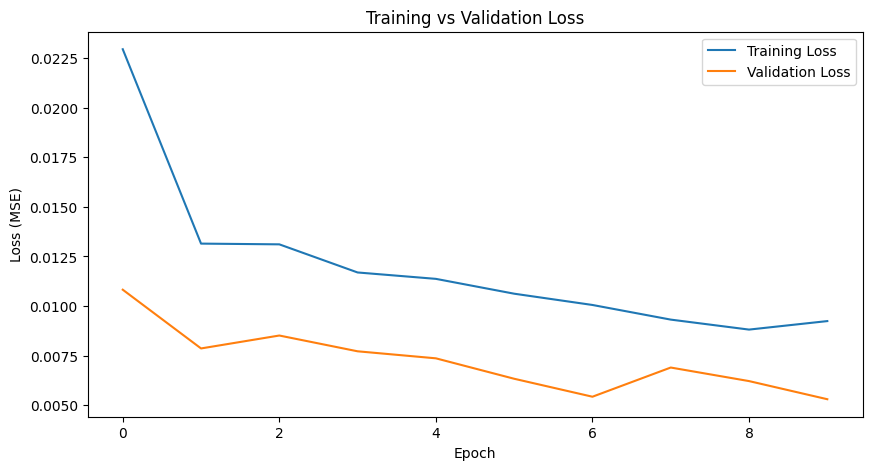

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


In [26]:
model.save('model.h5')
